# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

In [2]:
sample_image = skimage.data.coffee()

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8'));

sample image shape:  (400, 600, 3)


### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy()
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


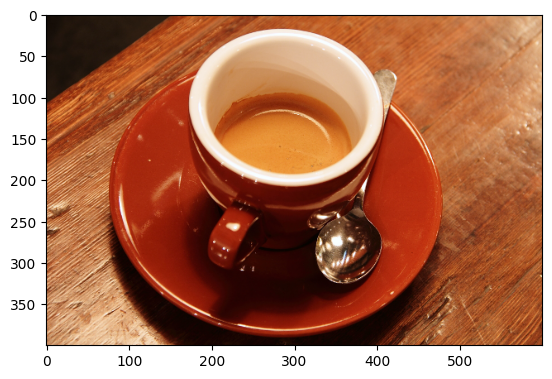

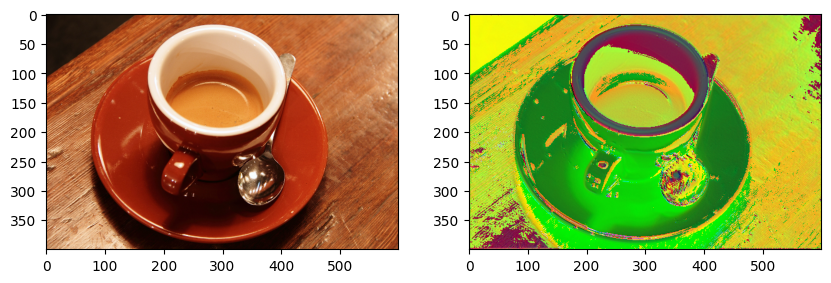

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8'))
ax1.imshow(np_img_out.astype('uint8'))
plt.show()

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 25
    array[:, :, 1, 1] = 1 / 25
    array[:, :, 2, 2] = 1 / 25
    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)

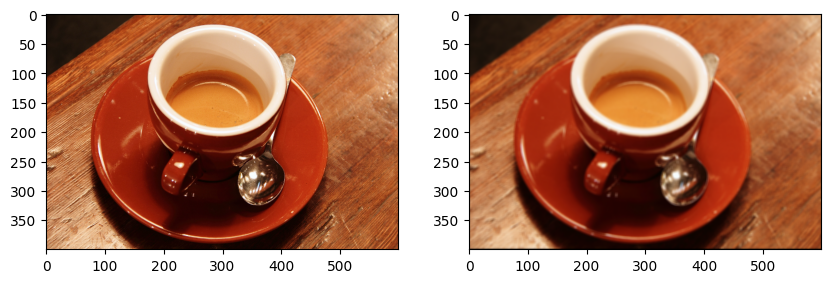

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'))

plt.show()

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

## Exercise: try kernel_size = (10,10) and padding is 'valid'

In [13]:
conv_exercise = Conv2D(filters=3, kernel_size=(10, 10), padding="valid", kernel_initializer=my_kernel)

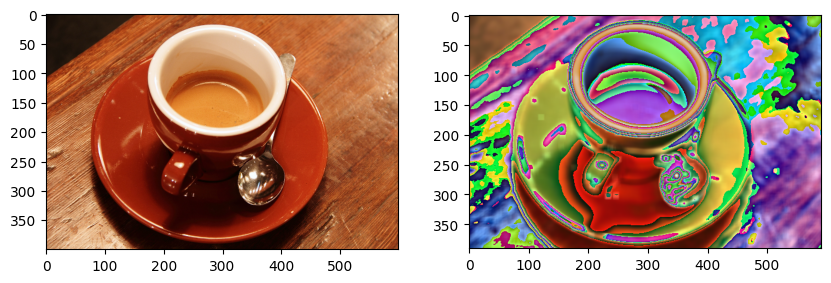

In [14]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv_exercise(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'))

plt.show()

## Exercise: try kernel_size = (50,50) and padding is 'valid'

In [15]:
conv_exercise2 = Conv2D(filters=3, kernel_size=(50, 50), padding="valid", kernel_initializer=my_kernel)

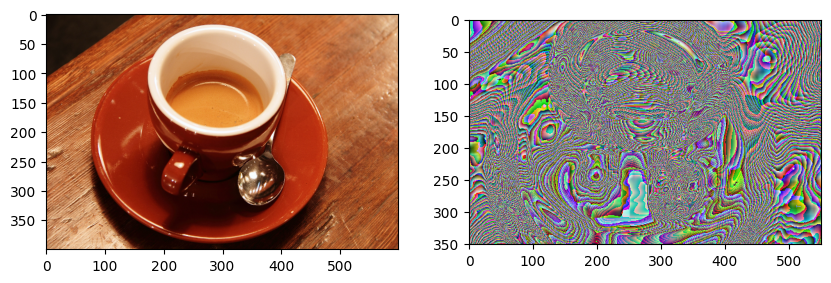

In [16]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv_exercise2(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'))

plt.show()

### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

In [17]:
# convert image to greyscale
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)),
           cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

## Exercise: Try Kernel Sobel X

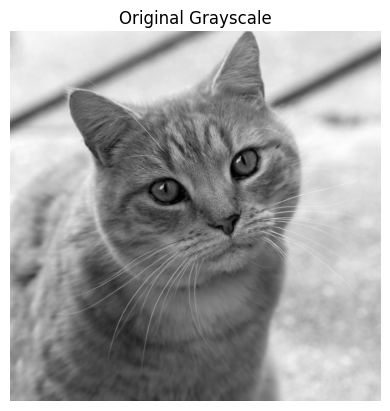

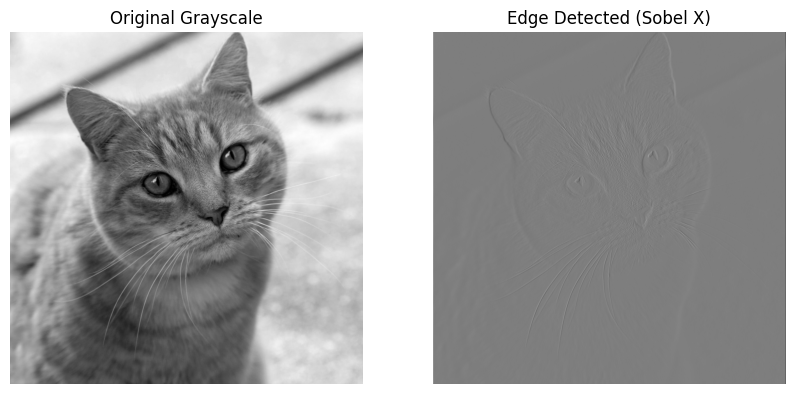

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

sample_image = image.img_to_array(image.load_img("Cat03.jpg"))

# Convert to Grayscale
grey_sample_image = sample_image.mean(axis=2)                      # average RGB channels
grey_sample_image = grey_sample_image[:, :, np.newaxis]            # add channel dim (H, W, 1)

plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
plt.title("Original Grayscale")
plt.axis("off")
plt.show()

# Define Custom Kernel Initializer
def my_kernel(shape=(3, 3, 1, 1), dtype=None):
    kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    # reshape into (height, width, input_channels, output_channels)
    kernel = kernel.reshape(*shape)
    return tf.constant(kernel, dtype=dtype)

# Build the Conv2D Layer 
conv = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    padding="same",
    kernel_initializer=my_kernel,
    use_bias=False
)

# Apply the Kernel
img_in = np.expand_dims(grey_sample_image, 0)  # add batch dimension
img_out = conv(img_in)
np_img_out = img_out[0].numpy()

# Normalize Output for Display
np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min())

# Plot Results 
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title("Original Grayscale")
ax0.axis("off")
ax1.imshow(np.squeeze(np_img_out), cmap=plt.cm.gray)
ax1.set_title("Edge Detected (Sobel X)")
ax1.axis("off")
plt.show()

## Exercise: Try Kernel Laplacian

In [19]:
# Define Custom Kernel Initializer
def my_kernel_laplacian(shape=(3, 3, 1, 1), dtype=None):
    kernel = np.array([
        [0, -1, 0],
        [-1, 4, -1],
        [0, -1, 0]
    ], dtype=np.float32)

    # reshape into (height, width, input_channels, output_channels)
    kernel = kernel.reshape(*shape)
    return tf.constant(kernel, dtype=dtype)

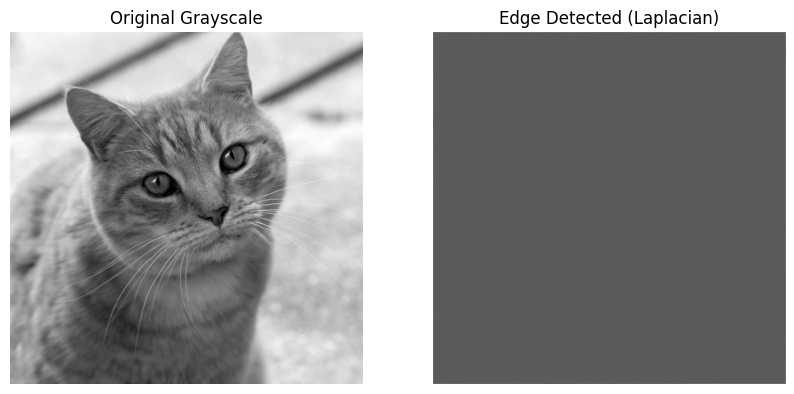

In [20]:
# Build the Conv2D Layer 
conv_laplacian = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    padding="same",
    kernel_initializer=my_kernel_laplacian,
    use_bias=False
)
# Apply the Kernel
img_in = np.expand_dims(grey_sample_image, 0)  # add batch dimension
img_out = conv_laplacian(img_in)
np_img_out = img_out[0].numpy()

# Normalize Output for Display 
np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min())

# Plot Results 
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title("Original Grayscale")
ax0.axis("off")
ax1.imshow(np.squeeze(np_img_out), cmap=plt.cm.gray)
ax1.set_title("Edge Detected (Laplacian)")
ax1.axis("off")
plt.show()

## Exercise: Try Kernel Sobel Y

In [21]:
# Define Custom Kernel Initializer 
def my_kernel_sobel_y(shape=(3, 3, 1, 1), dtype=None):
    kernel = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32)

    # reshape into (height, width, input_channels, output_channels)
    kernel = kernel.reshape(*shape)
    return tf.constant(kernel, dtype=dtype)

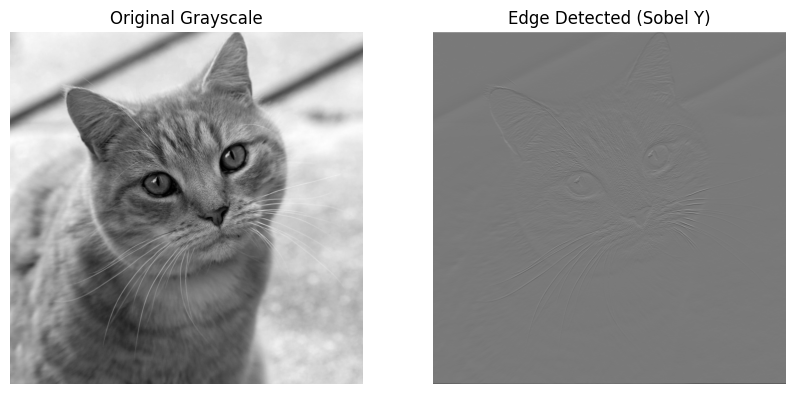

In [22]:
# Build the Conv2D Layer 
conv_sobel_y = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    padding="same",
    kernel_initializer=my_kernel_sobel_y,
    use_bias=False
)
# Apply the Kernel 
img_in = np.expand_dims(grey_sample_image, 0)  # add batch dimension
img_out = conv_sobel_y(img_in)
np_img_out = img_out[0].numpy()

# Normalize Output for Display 
np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min())

# Plot Results 
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title("Original Grayscale")
ax0.axis("off")
ax1.imshow(np.squeeze(np_img_out), cmap=plt.cm.gray)
ax1.set_title("Edge Detected (Sobel Y)")
ax1.axis("off")
plt.show()

## Exercise: Try Kernel Prewitt X

In [23]:
# Define Custom Kernel Initializer
def my_kernel_prewitt_x(shape=(3, 3, 1, 1), dtype=None):
    kernel = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32)

    # reshape into (height, width, input_channels, output_channels)
    kernel = kernel.reshape(*shape)
    return tf.constant(kernel, dtype=dtype)

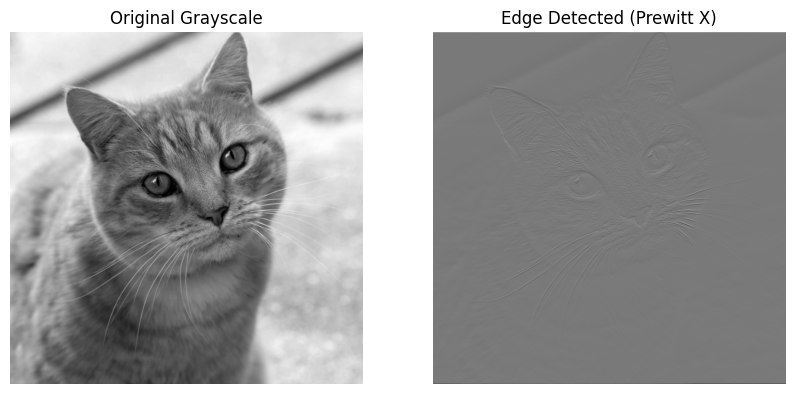

In [24]:
# Build the Conv2D Layer 
conv_prewitt_x = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    padding="same",
    kernel_initializer=my_kernel_prewitt_x,
    use_bias=False
)
# Apply the Kernel 
img_in = np.expand_dims(grey_sample_image, 0)  # add batch dimension
img_out = conv_prewitt_x(img_in)
np_img_out = img_out[0].numpy()

# Normalize Output for Display
np_img_out = (np_img_out - np_img_out.min()) / (np_img_out.max() - np_img_out.min())

# Plot Results
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)
ax0.set_title("Original Grayscale")
ax0.axis("off")
ax1.imshow(np.squeeze(np_img_out), cmap=plt.cm.gray)
ax1.set_title("Edge Detected (Prewitt X)")
ax1.axis("off")
plt.show()

### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

## Exercise : Pooling and strides with convolutions

In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load image directly as grayscale
sample_image = image.img_to_array(
    image.load_img("Cat03.jpg", color_mode="grayscale")
)

# shape is now (H, W, 1)
img_in = np.expand_dims(sample_image, 0)  # add batch dim -> (1, H, W, 1)

print("Image shape:", img_in.shape)

Image shape: (1, 1598, 1600, 1)


Original shape: (1, 1598, 1600, 1)
After MaxPool2D shape: (1, 799, 800, 1)
After AvgPool2D shape: (1, 799, 800, 1)


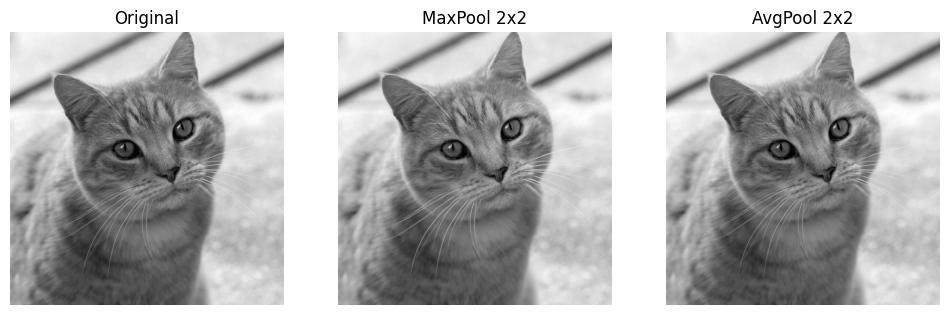

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, AvgPool2D
import matplotlib.pyplot as plt

print("Original shape:", img_in.shape)

# Max Pooling
maxpool = MaxPool2D(pool_size=(2, 2), strides=2)
maxpooled = maxpool(img_in)
print("After MaxPool2D shape:", maxpooled.shape)

# Average Pooling 
avgpool = AvgPool2D(pool_size=(2, 2), strides=2)
avgpooled = avgpool(img_in)
print("After AvgPool2D shape:", avgpooled.shape)

# Plot comparison 
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap='gray')
axs[0].set_title("Original")
axs[1].imshow(np.squeeze(maxpooled[0].numpy()), cmap='gray')
axs[1].set_title("MaxPool 2x2")
axs[2].imshow(np.squeeze(avgpooled[0].numpy()), cmap='gray')
axs[2].set_title("AvgPool 2x2")
for ax in axs:
    ax.axis("off")
plt.show()

## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

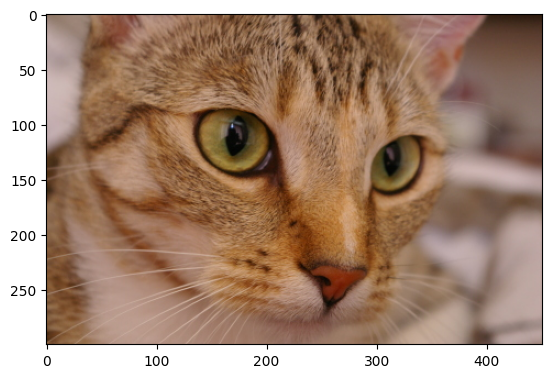

In [27]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image)
plt.show()

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [28]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
lowres_image.shape

(50, 50, 3)

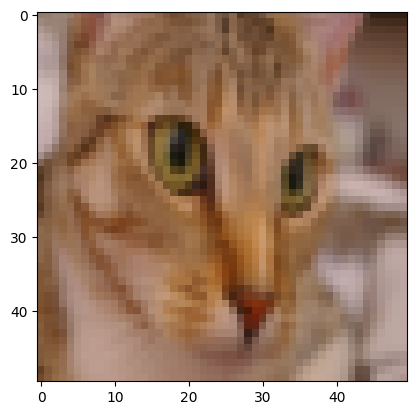

In [29]:
plt.imshow(lowres_image, interpolation='nearest')
plt.show()

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [30]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
model.compile(optimizer='sgd', loss='categorical_crossentropy')

In [31]:
print(model.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

## Exercise: image cat from above

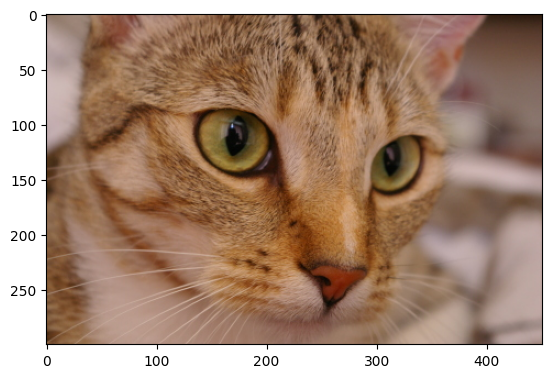

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1. Egyptian_cat: 56.11%
2. window_screen: 6.75%
3. Siamese_cat: 5.44%


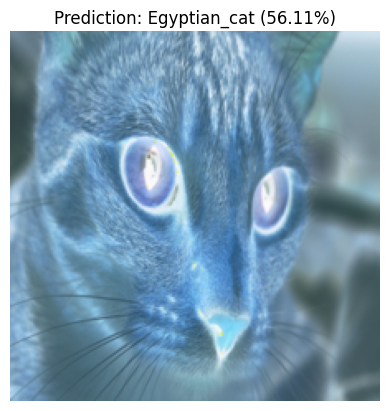

In [32]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread

image_array = skimage.data.cat()
plt.imshow(image_array)
plt.show()

# Save temporarily or convert to PIL directly
from PIL import Image
img_pil = Image.fromarray((image_array * 255).astype('uint8'))  # skimage images are 0–1 floats
img_pil = img_pil.resize((224, 224))

# Convert to array and preprocess
x = image.img_to_array(img_pil)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img_pil)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()


## Exercise: try to use the low resolution image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1. Egyptian_cat: 73.26%
2. tiger_cat: 14.59%
3. tabby: 11.69%


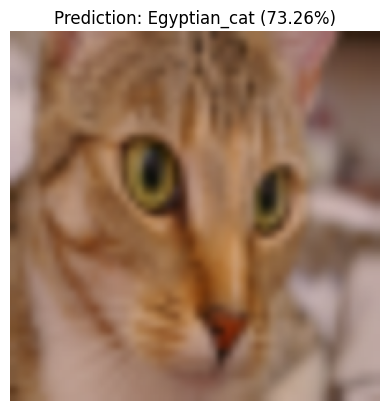

In [33]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Save temporarily or convert to PIL directly
from PIL import Image
img_pil = Image.fromarray((lowres_image * 255).astype('uint8'))  # skimage images are 0–1 floats
img_pil = img_pil.resize((224, 224))

# Convert to array and preprocess
x = image.img_to_array(img_pil)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img_pil)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()


## Exercise: Using the downloaded image from Wikipedia

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1. Egyptian_cat: 39.85%
2. tiger_cat: 36.34%
3. tabby: 20.45%


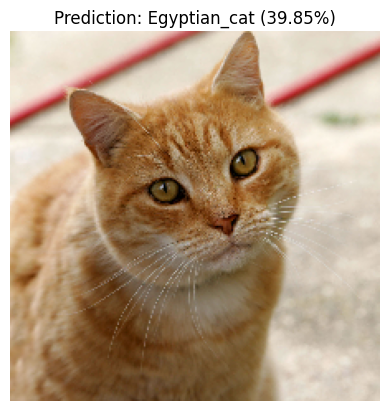

In [34]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#  Load image properly 
img_path = "Cat03.jpg"  # your downloaded file
img = image.load_img(img_path, target_size=(224, 224))  # ensure 3 channels (RGB)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()


## Exercise: try the image of Sphynx Cat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1. Mexican_hairless: 23.99%
2. Egyptian_cat: 17.57%
3. Chihuahua: 11.14%


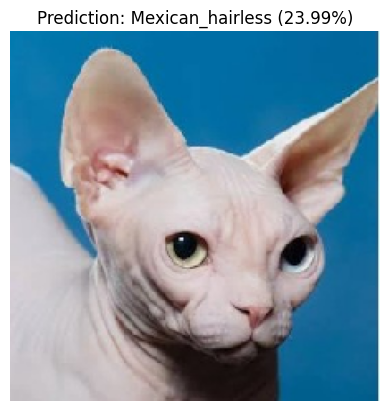

In [35]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#  Load image properly 
img_path = "sphynx_cat.jpg"  # your downloaded file
img = image.load_img(img_path, target_size=(224, 224))  # ensure 3 channels (RGB)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()


Result: this is the result of top 3 predictions because by adding all the percentage the result is not 1. This is example where the pre trained model prediction is wrong.

## Exercise: try image of tiger

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1. tiger: 59.43%
2. tiger_cat: 40.08%
3. lynx: 0.26%


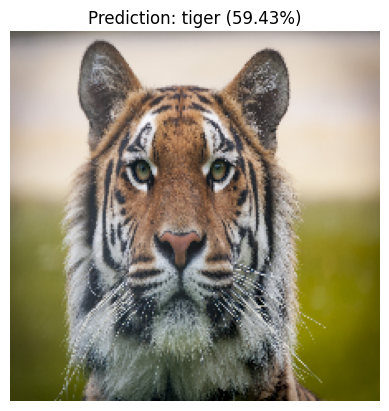

In [36]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#  Load image properly 
img_path = "tiger.jpg"  # your downloaded file
img = image.load_img(img_path, target_size=(224, 224))  # ensure 3 channels (RGB)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()

## Exercise: try image of lion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1. lion: 99.69%
2. macaque: 0.08%
3. chow: 0.06%


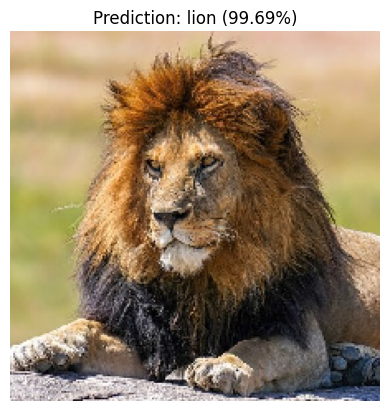

In [37]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#  Load image properly 
img_path = "lion.jpg"  # your downloaded file
img = image.load_img(img_path, target_size=(224, 224))  # ensure 3 channels (RGB)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)  # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()

##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

In [38]:
import cv2

def camera_grab(camera_id=0, fallback_filename=None):
    camera = cv2.VideoCapture(camera_id)
    try:
        # take 10 consecutive snapshots to let the camera automatically tune
        # itself and hope that the contrast and lighting of the last snapshot
        # is good enough.
        for i in range(10):
            snapshot_ok, image = camera.read()
        if snapshot_ok:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            print("WARNING: could not access camera")
            if fallback_filename:
                image = imread(fallback_filename)
    finally:
        camera.release()
    return image

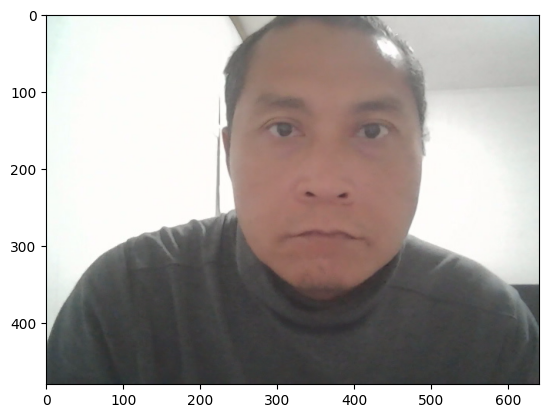

dtype: uint8, shape: (480, 640, 3), range: (np.uint8(37), np.uint8(255))


In [41]:
image_camera = camera_grab(camera_id=0, fallback_filename=None)
plt.imshow(image_camera)
plt.show()
print("dtype: {}, shape: {}, range: {}".format(
    image_camera.dtype, image_camera.shape, (image_camera.min(), image_camera.max())))

### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1. mask: 56.32%
2. seat_belt: 5.94%
3. ski_mask: 3.87%


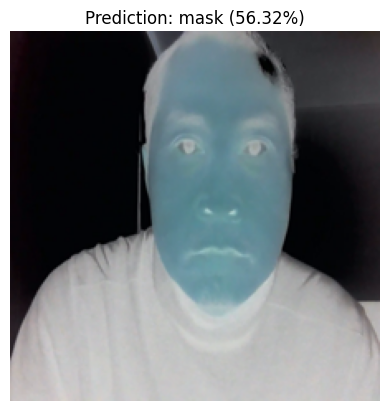

In [42]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Save temporarily or convert to PIL directly
from PIL import Image
img_pil = Image.fromarray((image_camera * 255).astype('uint8'))  # skimage images are 0–1 floats
img_pil = img_pil.resize((224, 224))

# Convert to array and preprocess
x = image.img_to_array(img_pil)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) # normalize for ResNet50

# Predict 
preds = model.predict(x)

# Decode and print top 3 predictions 
decoded = decode_predictions(preds, top=3)[0]
for i, (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label}: {score*100:.2f}%")

# Show the image 
plt.imshow(img_pil)
plt.title(f"Prediction: {decoded[0][1]} ({decoded[0][2]*100:.2f}%)")
plt.axis('off')
plt.show()

Result: It can not predict human and I'm the mask lol.